In [8]:
import os
import requests
import numpy as np
import PIL.Image as Image
import keras
import keras_hub
import time
import io
import matplotlib.pyplot as plt

In [6]:
# Load the ImageNet class names
classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(classes_url)
imagenet_labels = response.text.splitlines()

# Load ViT Components
# The preprocessor handles resizing to 224x224 and necessary normalization
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

# Load the classifier
classifier = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    preprocessor=preprocessor
)

In [7]:
image_urls = [
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba", # Cat
    "https://images.unsplash.com/photo-1552053831-71594a27632d", # Golden Retriever
    "https://images.unsplash.com/photo-1567306226416-28f0efdc88ce", # Apple
    "https://images.unsplash.com/photo-1614728894747-a83421e2b9c9", # Space/Telescope context
    "https://images.unsplash.com/photo-1536590158209-e9d615d525e4"  # Coffee Mug
]

headers = {'User-Agent': 'Mozilla/5.0'}
results = []

for url in image_urls:
    try:
        response = requests.get(url, stream=True, headers=headers)
        response.raise_for_status()

        img = Image.open(io.BytesIO(response.content)).convert("RGB")
        img_array = np.array(img)

        # ViT prediction
        predictions = classifier.predict(np.expand_dims(img_array, axis=0), verbose=0)
        top_index = np.argmax(predictions, axis=-1)[0]
        predicted_label = imagenet_labels[top_index]

        results.append(predicted_label)
        print(f"URL: {url[-10:]} | Predicted: {predicted_label}")

        # Brief pause to be polite to servers
        time.sleep(1)

    except Exception as e:
        print(f"Error: {e}")
        results.append("Error")

URL: 03e2ca1dba | Predicted: Egyptian cat
URL: 594a27632d | Predicted: golden retriever
URL: f0efdc88ce | Predicted: Granny Smith
URL: 3421e2b9c9 | Predicted: planetarium
URL: d615d525e4 | Predicted: tiger cat


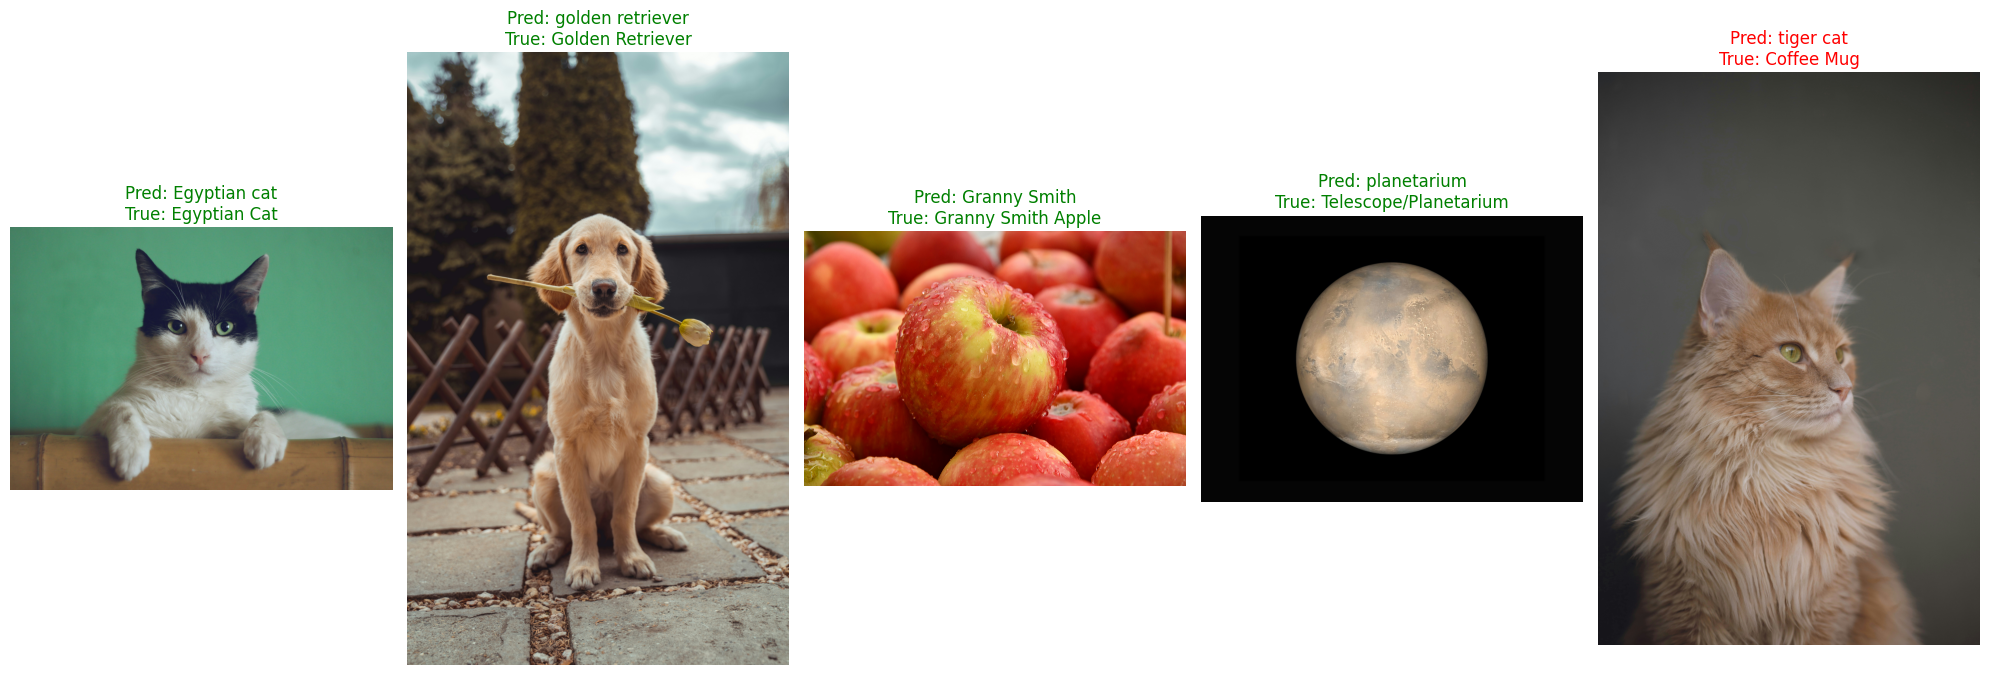

In [9]:
def visualize_results(image_urls, results, true_labels):
    plt.figure(figsize=(20, 10))

    for i, url in enumerate(image_urls):
        try:
            # Download image for display
            response = requests.get(url, headers=headers)
            img = Image.open(io.BytesIO(response.content))

            # Create subplot
            plt.subplot(1, 5, i + 1)
            plt.imshow(img)

            color = 'green' if results[i].lower() in true_labels[i].lower() or \
                           true_labels[i].lower() in results[i].lower() else 'red'

            plt.title(f"Pred: {results[i]}\nTrue: {true_labels[i]}", color=color, fontsize=12)
            plt.axis('off')
        except Exception as e:
            print(f"Could not visualize {url}: {e}")

    plt.tight_layout()
    plt.show()

# Define what you actually searched for
true_labels = ["Egyptian Cat", "Golden Retriever", "Granny Smith Apple", "Telescope/Planetarium", "Coffee Mug"]

# Run the visualization
visualize_results(image_urls, results, true_labels)